X_test shape: torch.Size([20, 3361, 8])


C:\Users\logan\AppData\Local\Temp\ipykernel_19204\1398650275.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_loca

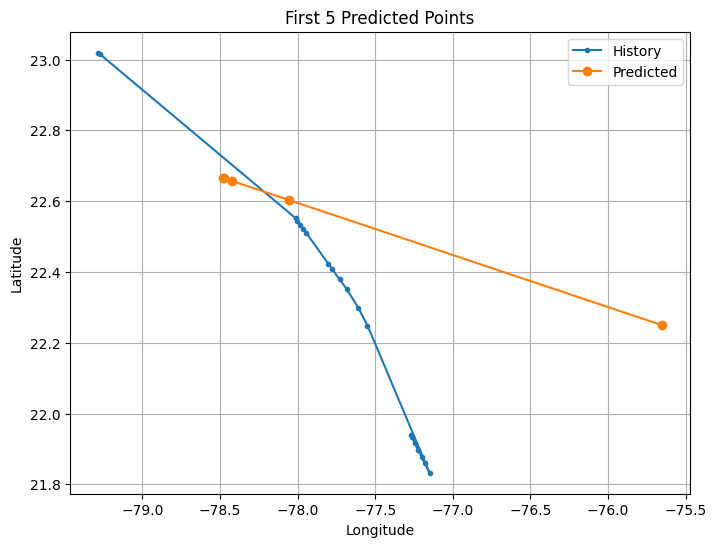

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Model classes
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(output_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, cell):
        out, (hidden, cell) = self.lstm(x, (hidden, cell))
        pred = self.linear(out[-1])
        return pred, hidden, cell


class EncoderDecoderLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size, num_layers)
        self.decoder = Decoder(output_size, hidden_size, num_layers)

    def forward(self, x, target_len):
        hidden, cell = self.encoder(x)
        decoder_input = x[-1, :, :2].unsqueeze(0)   # last LAT/LON
        outputs = []

        for _ in range(target_len):
            pred, hidden, cell = self.decoder(decoder_input, hidden, cell)
            outputs.append(pred)
            decoder_input = pred.unsqueeze(0)

        return torch.stack(outputs, dim=0)


# -----------------------------
# Build windows
# -----------------------------
def make_input_windows(df, feature_cols, seq_len=20):
    X_list = []

    values = df[feature_cols].to_numpy(dtype=np.float32)

    for i in range(len(df) - seq_len + 1):
        x_window = values[i:i+seq_len]
        X_list.append(x_window)

    X = np.stack(X_list)                  # (N, seq_len, features)
    X = np.transpose(X, (1, 0, 2))        # (seq_len, N, features)
    return torch.tensor(X, dtype=torch.float32)


# -----------------------------
# Read test file
# -----------------------------
df = pd.read_csv("model_data/gold_test_data.csv")


feature_cols = ["LAT", "LON", "SPEED", "dt", "cog_sin", "cog_cos", "hdg_sin", "hdg_cos"]


# -----------------------------
# Make model input
# -----------------------------
seq_len = 20
target_len = 5

X_test = make_input_windows(df, feature_cols, seq_len=seq_len).to(device)

print("X_test shape:", X_test.shape)   # should be (seq_len, N, 8)


# -----------------------------
# Load model
# -----------------------------
input_size = 8
hidden_size = 128   # replace with your trained value
num_layers = 3      # based on your saved checkpoint
output_size = 2

model = EncoderDecoderLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=output_size
).to(device)

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()


# -----------------------------
# Predict
# -----------------------------
with torch.no_grad():
    pred = model(X_test, target_len=target_len)

pred = pred.cpu().numpy()   # (target_len, N, 2)

In [ ]:
import folium

# Center map on first history point
center_lat = history[0, 0]
center_lon = history[0, 1]

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# History points
history_coords = [(row[0], row[1]) for row in history]

# Predicted points
pred_coords = [(row[0], row[1]) for row in pred_5]

# Draw history track
folium.PolyLine(
    history_coords,
    weight=3,
    tooltip="History"
).add_to(m)

# Draw predicted track
folium.PolyLine(
    pred_coords,
    weight=3,
    dash_array="5, 8",
    tooltip="Predicted"
).add_to(m)

# Add markers for history
for i, (lat, lon) in enumerate(history_coords):
    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        popup=f"History {i}",
        fill=True
    ).add_to(m)

# Add markers for predicted points
for i, (lat, lon) in enumerate(pred_coords, start=1):
    folium.Marker(
        location=[lat, lon],
        popup=f"Predicted {i}",
        tooltip=f"Predicted {i}"
    ).add_to(m)

m